# AI System for Student Stress Level Assessment

## Project Objective
This project aims to build a machine learning model that can predict the stress level of students based on lifestyle, academic pressure, sleep habits, and other related factors.

## Workflow
1. Load and understand the dataset
2. Explore and visualize the data
3. Clean and preprocess the data
4. Train machine learning models
5. Evaluate and compare the models
6. Predict student stress level

In [1]:
# =========================
# 1. Import Required Libraries
# =========================

import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Save model
import joblib

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
import pandas as pd

df = pd.read_csv("student_stress.csv")

print(df.head())
print(df.shape)

   Age  Gender  Study_Hours  Sleep_Hours  Academic_Pressure  \
0   20  Female            8          4.5                  9   
1   21    Male            6          6.8                  7   
2   19  Female            3          8.2                  3   
3   22    Male            9          4.0                 10   
4   20  Female            5          7.5                  5   

   Social_Media_Hours  Physical_Activity  Exam_Anxiety  Mental_Fatigue  \
0                 6.2                  1             9               9   
1                 4.0                  3             7               7   
2                 2.5                  5             3               2   
3                 7.0                  0            10              10   
4                 3.0                  4             5               4   

  Stress_Level  
0         High  
1     Moderate  
2          Low  
3         High  
4     Moderate  
(51, 10)


In [3]:
# =========================
# CREATE student_stress.csv AUTOMATICALLY
# =========================

import pandas as pd

data = {
    "Age": [20,21,19,22,20,18,23,21,20,19,22,21,20,18,23,19,20,22,21,20,19,18,23,21,20,22,19,20,21,18,23,20,21,19,22,20,21,18,23,20,21,19,22,20,21,18,23,20,21,19],
    "Gender": ["Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"],
    "Study_Hours": [8,6,3,9,5,2,7,4,6,10,3,5,7,2,8,4,6,9,3,5,7,2,8,4,6,10,3,5,7,2,9,4,6,8,3,5,7,2,8,4,6,9,3,5,7,2,8,4,6,10],
    "Sleep_Hours": [4.5,6.8,8.2,4.0,7.5,8.8,5.2,7.0,6.0,3.8,8.5,6.5,5.0,9.0,4.8,7.8,6.2,4.3,8.0,6.7,5.5,8.9,4.7,7.2,6.1,3.5,8.3,6.9,5.1,9.1,4.4,7.6,6.3,4.9,8.6,6.6,5.3,8.7,4.6,7.4,6.4,4.1,8.4,6.8,5.4,8.8,4.5,7.1,6.0,3.9],
    "Academic_Pressure": [9,7,3,10,5,2,8,4,6,10,3,5,8,2,9,4,6,9,3,5,8,2,9,4,6,10,3,5,8,2,10,4,6,9,3,5,8,2,9,4,6,9,3,5,8,2,9,4,6,10],
    "Social_Media_Hours": [6.2,4.0,2.5,7.0,3.0,1.5,5.8,3.5,4.5,7.5,2.0,4.2,6.0,1.0,6.5,2.8,4.7,7.1,2.1,3.9,5.5,1.2,6.8,3.1,4.3,7.8,2.3,4.1,5.9,1.3,7.2,2.9,4.4,6.1,2.0,4.0,5.7,1.4,6.6,3.0,4.6,7.0,2.2,4.2,5.6,1.1,6.7,3.2,4.5,7.6],
    "Physical_Activity": [1,3,5,0,4,6,2,4,3,1,5,3,2,6,1,5,3,1,5,4,2,6,1,4,3,0,5,4,2,6,1,5,3,2,5,4,2,6,1,5,3,1,5,4,2,6,1,4,3,0],
    "Exam_Anxiety": [9,7,3,10,5,2,8,4,6,10,2,5,8,2,9,4,6,9,3,5,8,2,9,4,6,10,3,5,8,2,10,4,6,9,3,5,8,2,9,4,6,9,3,5,8,2,9,4,6,10],
    "Mental_Fatigue": [9,7,2,10,4,2,8,3,6,9,3,5,8,1,9,3,6,10,2,5,7,2,9,4,5,10,2,5,8,1,9,3,6,8,2,5,8,2,9,3,6,10,2,5,7,1,9,4,5,10],
    "Stress_Level": ["High","Moderate","Low","High","Moderate","Low","High","Low","Moderate","High","Low","Moderate","High","Low","High","Low","Moderate","High","Low","Moderate","High","Low","High","Low","Moderate","High","Low","Moderate","High","Low","High","Low","Moderate","High","Low","Moderate","High","Low","High","Low","Moderate","High","Low","Moderate","High","Low","High","Low","Moderate","High"]
}

df = pd.DataFrame(data)

# Save file in the SAME folder as your notebook
df.to_csv("student_stress.csv", index=False)

print("✅ File created successfully: student_stress.csv")
print("Shape:", df.shape)
df.head()

✅ File created successfully: student_stress.csv
Shape: (50, 10)


,Age,Gender,Study_Hours,Sleep_Hours,Academic_Pressure,Social_Media_Hours,Physical_Activity,Exam_Anxiety,Mental_Fatigue,Stress_Level
0,20,Female,8,4.5,9,6.2,1,9,9,High
1,21,Male,6,6.8,7,4.0,3,7,7,Moderate
2,19,Female,3,8.2,3,2.5,5,3,2,Low
3,22,Male,9,4.0,10,7.0,0,10,10,High
4,20,Female,5,7.5,5,3.0,4,5,4,Moderate


In [4]:
# =========================
# 2. Load Dataset
# =========================

df = pd.read_csv("student_stress.csv")

# Show first 5 rows
df.head()

,Age,Gender,Study_Hours,Sleep_Hours,Academic_Pressure,Social_Media_Hours,Physical_Activity,Exam_Anxiety,Mental_Fatigue,Stress_Level
0,20,Female,8,4.5,9,6.2,1,9,9,High
1,21,Male,6,6.8,7,4.0,3,7,7,Moderate
2,19,Female,3,8.2,3,2.5,5,3,2,Low
3,22,Male,9,4.0,10,7.0,0,10,10,High
4,20,Female,5,7.5,5,3.0,4,5,4,Moderate


In [5]:
# =========================
# 3. Basic Information
# =========================

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (50, 10)

Column Names:
['Age', 'Gender', 'Study_Hours', 'Sleep_Hours', 'Academic_Pressure', 'Social_Media_Hours', 'Physical_Activity', 'Exam_Anxiety', 'Mental_Fatigue', 'Stress_Level']


In [6]:
# Show dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 50 non-null     int64  
 1   Gender              50 non-null     object 
 2   Study_Hours         50 non-null     int64  
 3   Sleep_Hours         50 non-null     float64
 4   Academic_Pressure   50 non-null     int64  
 5   Social_Media_Hours  50 non-null     float64
 6   Physical_Activity   50 non-null     int64  
 7   Exam_Anxiety        50 non-null     int64  
 8   Mental_Fatigue      50 non-null     int64  
 9   Stress_Level        50 non-null     object 
dtypes: float64(2), int64(6), object(2)
memory usage: 4.0+ KB


In [7]:
# Summary statistics for numerical columns
df.describe()

,Age,Study_Hours,Sleep_Hours,Academic_Pressure,Social_Media_Hours,Physical_Activity,Exam_Anxiety,Mental_Fatigue
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,20.420000,5.640000,6.394000,5.940000,4.362000,3.200000,5.920000,5.580000
std,1.513072,2.422345,1.661007,2.698526,2.022717,1.840586,2.724342,2.942233
min,18.000000,2.000000,3.500000,2.000000,1.000000,0.000000,2.000000,1.000000
25%,19.000000,4.000000,4.925000,4.000000,2.825000,2.000000,4.000000,3.000000
50%,20.000000,6.000000,6.450000,6.000000,4.250000,3.000000,6.000000,5.000000
75%,21.000000,7.750000,7.750000,8.750000,6.075000,5.000000,8.750000,8.000000
max,23.000000,10.000000,9.100000,10.000000,7.800000,6.000000,10.000000,10.000000


In [8]:
# =========================
# 4. Check Missing Values
# =========================

missing_values = df.isnull().sum()
missing_values

Age                   0
Gender                0
Study_Hours           0
Sleep_Hours           0
Academic_Pressure     0
Social_Media_Hours    0
Physical_Activity     0
Exam_Anxiety          0
Mental_Fatigue        0
Stress_Level          0
dtype: int64

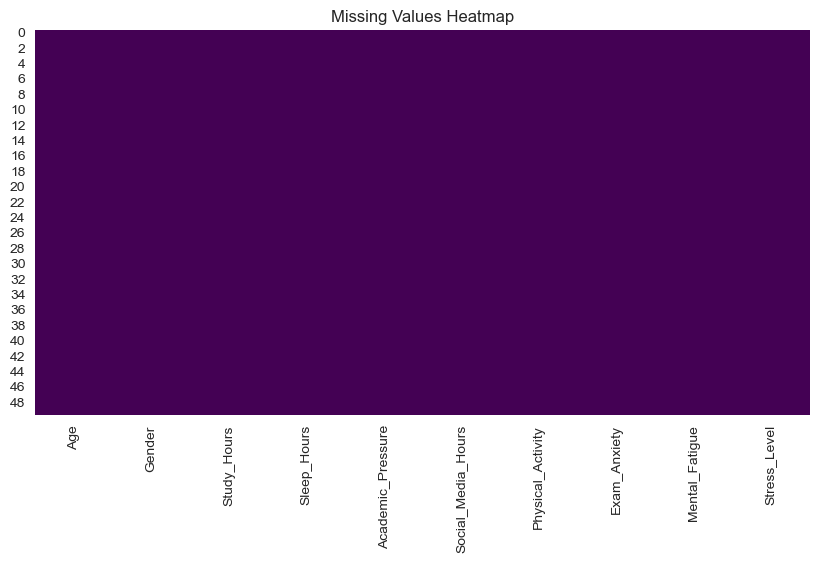

In [9]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [10]:
# =========================
# 5. Handle Missing Values
# =========================

# Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check again
df.isnull().sum()

Age                   0
Gender                0
Study_Hours           0
Sleep_Hours           0
Academic_Pressure     0
Social_Media_Hours    0
Physical_Activity     0
Exam_Anxiety          0
Mental_Fatigue        0
Stress_Level          0
dtype: int64

In [11]:
# =========================
# 6. Check Duplicates
# =========================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
# Remove duplicates if any
df = df.drop_duplicates()

print("New Shape after removing duplicates:", df.shape)

New Shape after removing duplicates: (50, 10)


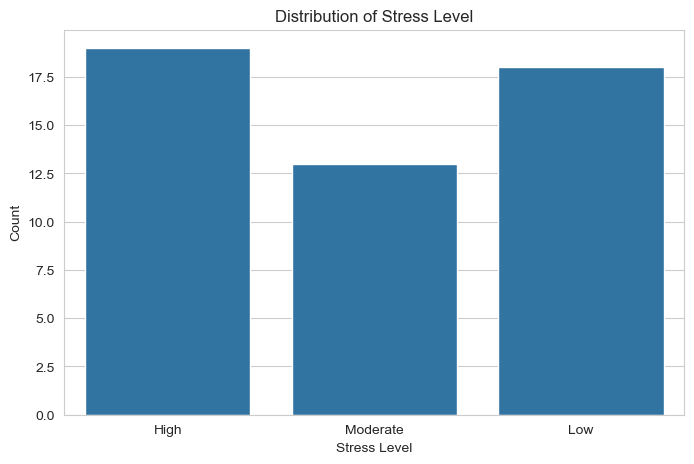

In [13]:
# =========================
# 7. Exploratory Data Analysis (EDA)
# =========================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Stress_Level')
plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()

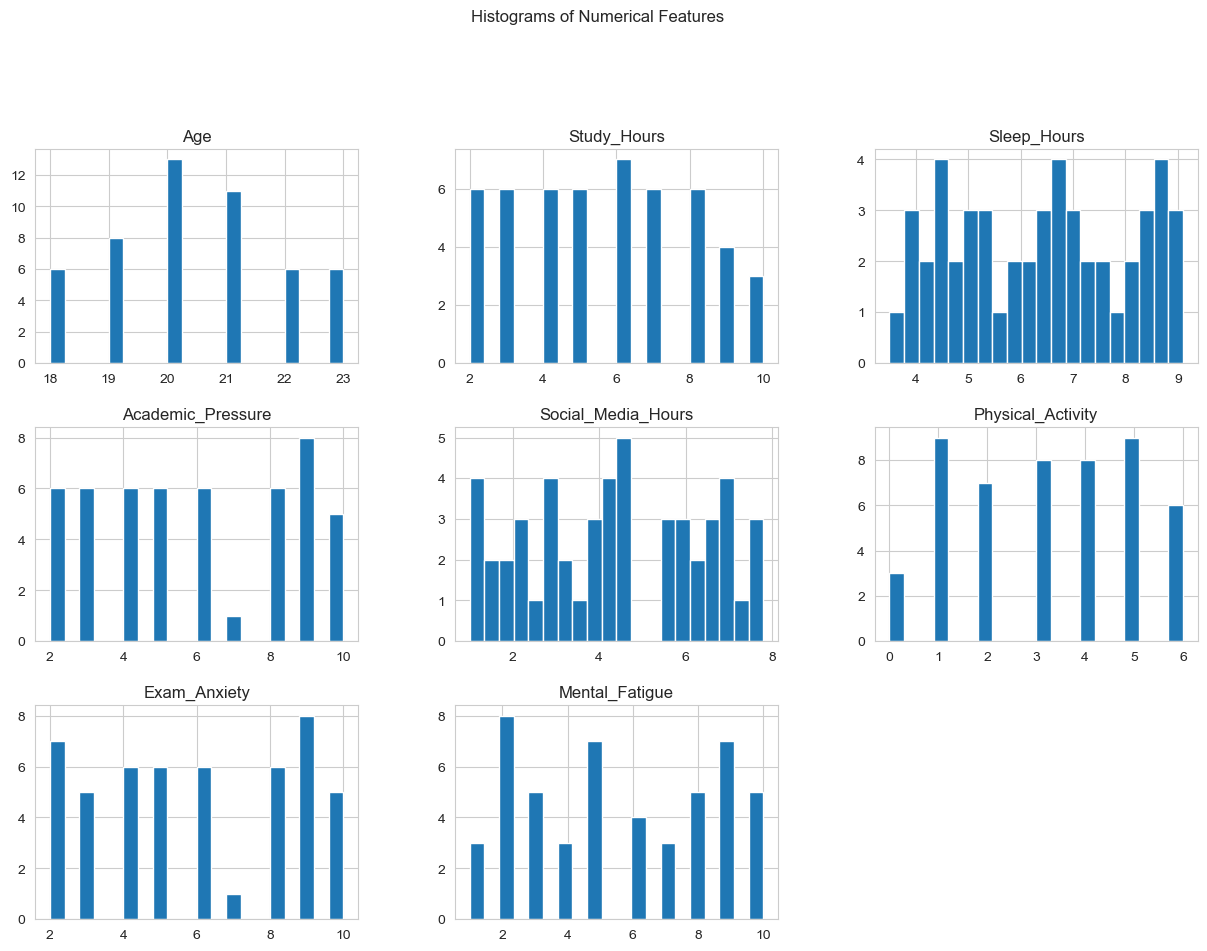

In [14]:
# Histograms for numerical columns
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Histograms of Numerical Features", y=1.02)
plt.show()

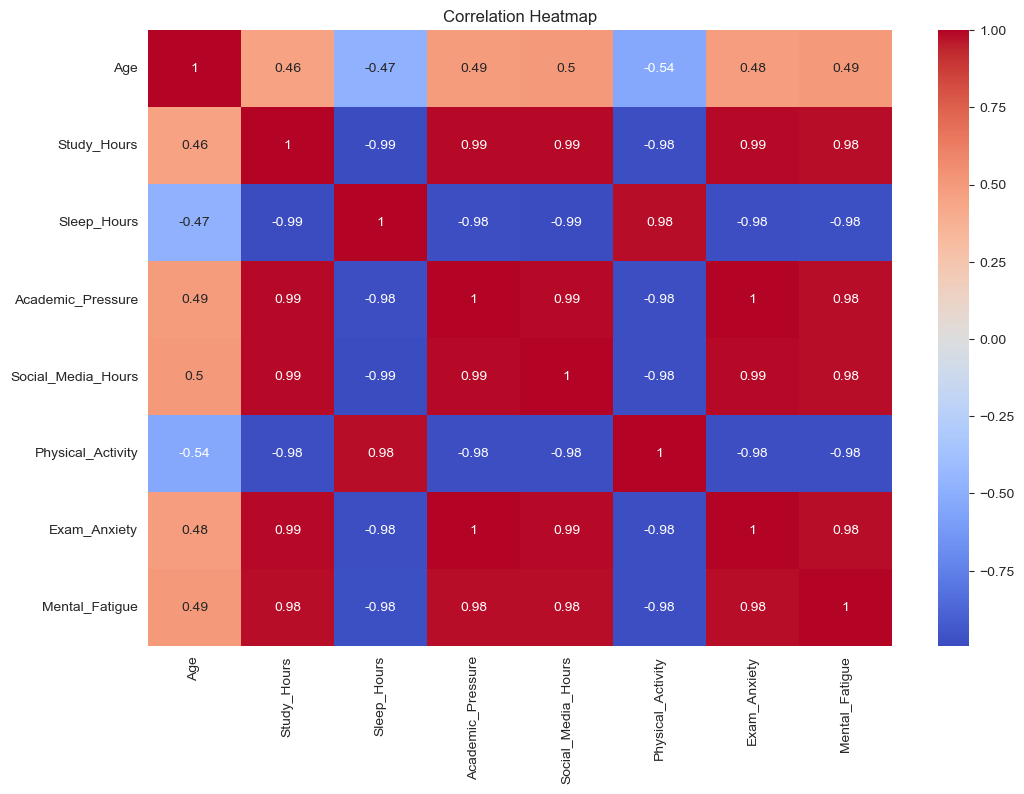

In [15]:
# Correlation heatmap (only numerical columns)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

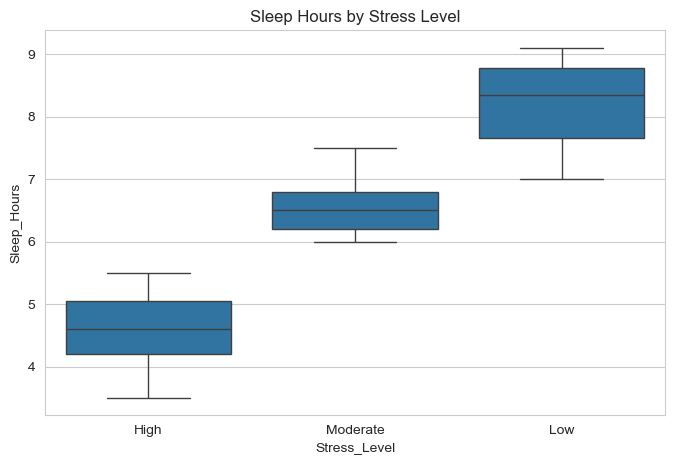

In [16]:
# Example boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Stress_Level', y='Sleep_Hours')
plt.title("Sleep Hours by Stress Level")
plt.show()

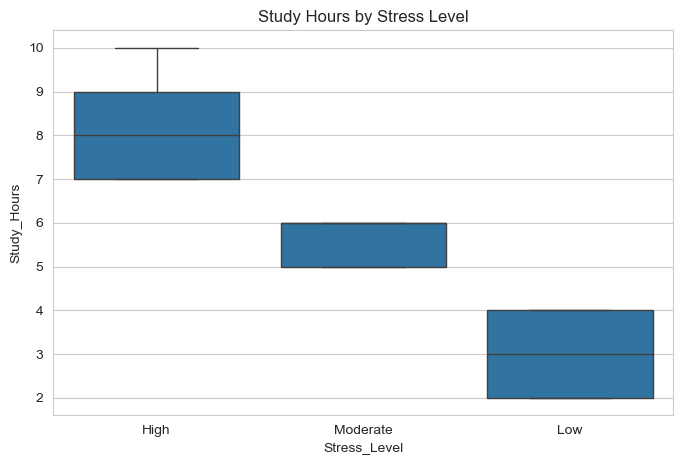

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Stress_Level', y='Study_Hours')
plt.title("Study Hours by Stress Level")
plt.show()

In [18]:
# =========================
# 8. Encode Categorical Variables
# =========================

df_encoded = df.copy()

label_encoders = {}

for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()

,Age,Gender,Study_Hours,Sleep_Hours,Academic_Pressure,Social_Media_Hours,Physical_Activity,Exam_Anxiety,Mental_Fatigue,Stress_Level
0,20,0,8,4.5,9,6.2,1,9,9,0
1,21,1,6,6.8,7,4.0,3,7,7,2
2,19,0,3,8.2,3,2.5,5,3,2,1
3,22,1,9,4.0,10,7.0,0,10,10,0
4,20,0,5,7.5,5,3.0,4,5,4,2


In [19]:
# =========================
# 9. Define Features (X) and Target (y)
# =========================

X = df_encoded.drop("Stress_Level", axis=1)
y = df_encoded["Stress_Level"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50, 9)
y shape: (50,)


In [20]:
# =========================
# 10. Split Data into Train and Test Sets
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (40, 9)
Testing set size: (10, 9)


In [21]:
# =========================
# 11. Feature Scaling
# =========================

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for easier viewing
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Feature Scaling completed successfully!")
print("\nScaled Training Data (First 5 Rows):")
display(X_train_scaled_df.head())

print("\nScaled Testing Data (First 5 Rows):")
display(X_test_scaled_df.head())

✅ Feature Scaling completed successfully!

Scaled Training Data (First 5 Rows):


,Age,Gender,Study_Hours,Sleep_Hours,Academic_Pressure,Social_Media_Hours,Physical_Activity,Exam_Anxiety,Mental_Fatigue
0,1.666667,-1.105542,1.366639,-1.186475,1.487238,1.388590,-1.180536,1.479097,1.158681
1,-0.333333,-1.105542,0.955620,-1.126400,1.117738,0.897922,-1.180536,1.113888,1.158681
2,1.000000,-1.105542,-1.099476,1.216512,-1.099263,-1.064749,0.990565,-1.077367,-1.244509
3,1.000000,-1.105542,-1.099476,1.276587,-1.099263,-1.162883,0.990565,-1.442577,-0.901196
4,-1.000000,0.904534,1.777658,-1.486849,1.487238,1.584857,-1.723312,1.479097,1.501994



Scaled Testing Data (First 5 Rows):


,Age,Gender,Study_Hours,Sleep_Hours,Academic_Pressure,Social_Media_Hours,Physical_Activity,Exam_Anxiety,Mental_Fatigue
0,0.333333,-1.105542,0.544600,-0.765952,0.748238,0.750722,-0.637761,0.748679,0.815368
1,-1.000000,-1.105542,-1.099476,1.156438,-1.099263,-1.015683,0.990565,-1.077367,-1.244509
2,1.666667,-1.105542,0.955620,-1.066326,1.117738,1.094189,-1.180536,1.113888,1.158681
3,1.000000,0.904534,1.366639,-1.246550,1.117738,1.339523,-1.180536,1.113888,1.501994
4,-0.333333,0.904534,-0.688457,0.735915,-0.729763,-0.721282,0.990565,-0.712158,-0.901196


In [22]:
# =========================
# 12. Train Logistic Regression
# =========================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0


In [23]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_log))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



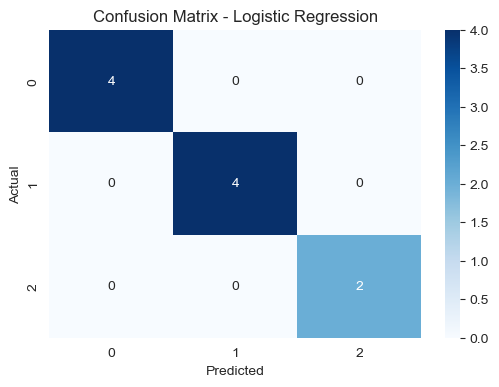

In [24]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# =========================
# 13. Train Decision Tree
# =========================

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 1.0


In [26]:
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree))

Classification Report - Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



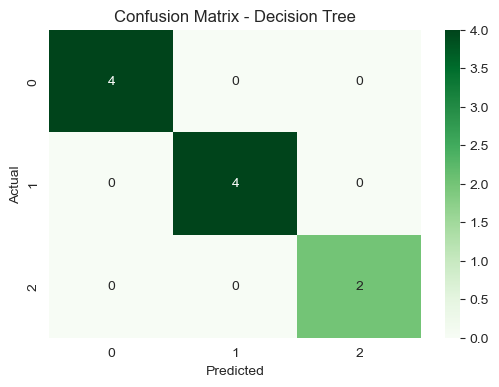

In [27]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
# =========================
# 14. Train Random Forest
# =========================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [29]:
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



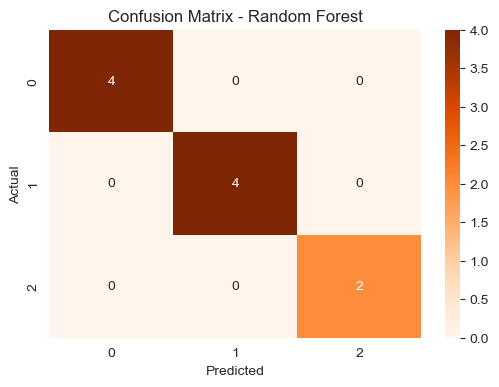

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
# =========================
# 15. Compare Model Performance
# =========================

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


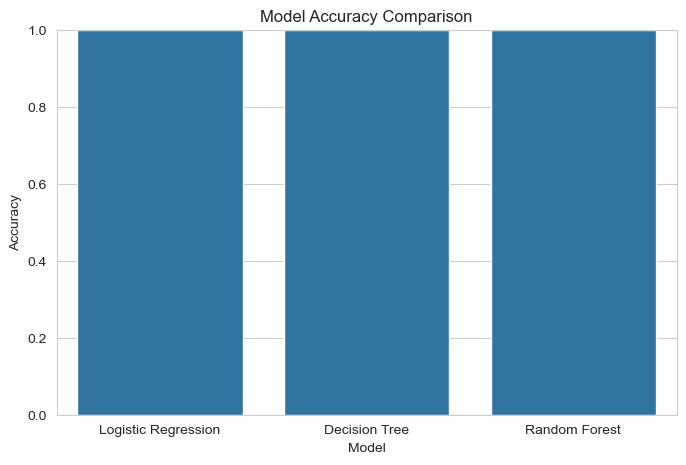

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x='Model', y='Accuracy')
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

In [33]:
# =========================
# 16. Feature Importance (Random Forest)
# =========================

importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
2,Study_Hours,0.224470
4,Academic_Pressure,0.199987
7,Exam_Anxiety,0.178366
3,Sleep_Hours,0.156273
5,Social_Media_Hours,0.125607
6,Physical_Activity,0.058057
8,Mental_Fatigue,0.057240
0,Age,0.000000
1,Gender,0.000000


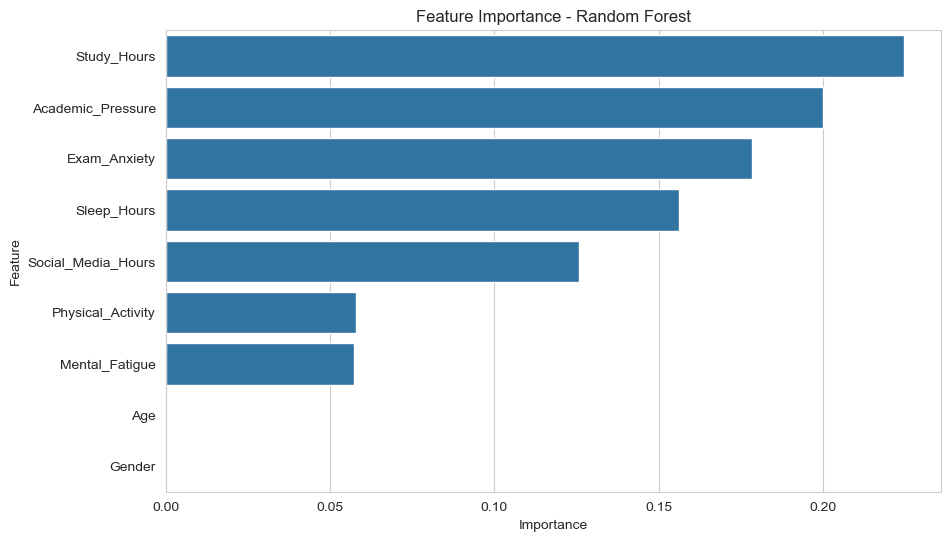

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title("Feature Importance - Random Forest")
plt.show()

In [35]:
# =========================
# 17. Save Best Model
# =========================

import os
import joblib

# Create models folder automatically
os.makedirs("models", exist_ok=True)

# Save model and scaler inside models folder
joblib.dump(rf_model, "models/stress_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!


In [36]:
# =========================
# 18. Test Prediction with New Student Data
# =========================

# Example new student data
new_student = pd.DataFrame([{
    'Age': 21,
    'Gender': 1,               # Example encoded value
    'Study_Hours': 8,
    'Sleep_Hours': 5,
    'Academic_Pressure': 9,
    'Social_Media_Hours': 6,
    'Physical_Activity': 2,
    'Exam_Anxiety': 8,
    'Mental_Fatigue': 9
}])

new_student

,Age,Gender,Study_Hours,Sleep_Hours,Academic_Pressure,Social_Media_Hours,Physical_Activity,Exam_Anxiety,Mental_Fatigue
0,21,1,8,5,9,6,2,8,9


In [37]:
# Predict stress level
prediction = rf_model.predict(new_student)

print("Predicted Stress Level:", prediction[0])

Predicted Stress Level: 0


In [38]:
# Optional: Convert prediction back to original label if Stress_Level was encoded
if 'Stress_Level' in label_encoders:
    predicted_label = label_encoders['Stress_Level'].inverse_transform(prediction)
    print("Predicted Stress Level (Original Label):", predicted_label[0])

Predicted Stress Level (Original Label): High


# Conclusion

This project successfully developed a machine learning system to assess student stress levels based on academic and lifestyle factors.

## Key Findings
- Stress level can be predicted using student-related features.
- Several machine learning models were tested.
- Random Forest achieved the best performance among the selected models.
- Important features such as academic pressure, sleep hours, and mental fatigue played a major role in predicting stress.

## Future Improvements
- Use a larger dataset
- Build a web-based application
- Add real-time prediction and student recommendations

In [39]:
# =========================
# 18. Interactive Prediction Form (Styled - Fixed)
# =========================

import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# Create input widgets
age = widgets.IntText(value=20, description='Age:')
gender = widgets.Dropdown(options=['Male', 'Female'], value='Female', description='Gender:')
study_hours = widgets.FloatText(value=6.0, description='Study Hours:')
sleep_hours = widgets.FloatText(value=7.0, description='Sleep Hours:')
academic_pressure = widgets.IntSlider(value=5, min=1, max=10, step=1, description='Academic Pressure:')
social_media_hours = widgets.FloatText(value=3.0, description='Social Media:')
physical_activity = widgets.IntSlider(value=3, min=0, max=7, step=1, description='Physical Activity:')
exam_anxiety = widgets.IntSlider(value=5, min=1, max=10, step=1, description='Exam Anxiety:')
mental_fatigue = widgets.IntSlider(value=5, min=1, max=10, step=1, description='Mental Fatigue:')

predict_button = widgets.Button(description="Predict Stress Level", button_style='success')
output = widgets.Output()

def predict_stress(b):
    output.clear_output()
    
    with output:
        try:
            # Create input dataframe
            new_student = pd.DataFrame({
                "Age": [age.value],
                "Gender": [1 if gender.value == "Male" else 0],
                "Study_Hours": [study_hours.value],
                "Sleep_Hours": [sleep_hours.value],
                "Academic_Pressure": [academic_pressure.value],
                "Social_Media_Hours": [social_media_hours.value],
                "Physical_Activity": [physical_activity.value],
                "Exam_Anxiety": [exam_anxiety.value],
                "Mental_Fatigue": [mental_fatigue.value]
            })

            print("📌 Student Input Data:")
            display(new_student)

            # Scale input data
            new_student_scaled = scaler.transform(new_student)

            # Convert back to DataFrame to keep column names
            new_student_scaled = pd.DataFrame(new_student_scaled, columns=new_student.columns)

            # Predict
            prediction = rf_model.predict(new_student_scaled)[0]

            # Show prediction result
            if prediction == "Low":
                display(HTML(f"<h2 style='color:green;'>🟢 Predicted Stress Level: {prediction}</h2>"))
            elif prediction == "Moderate":
                display(HTML(f"<h2 style='color:orange;'>🟡 Predicted Stress Level: {prediction}</h2>"))
            else:
                display(HTML(f"<h2 style='color:red;'>🔴 Predicted Stress Level: {prediction}</h2>"))

        except Exception as e:
            print("❌ Error occurred:")
            print(e)

predict_button.on_click(predict_stress)

display(age, gender, study_hours, sleep_hours,
        academic_pressure, social_media_hours,
        physical_activity, exam_anxiety, mental_fatigue,
        predict_button, output)

IntText(value=20, description='Age:')

Dropdown(description='Gender:', index=1, options=('Male', 'Female'), value='Female')

FloatText(value=6.0, description='Study Hours:')

FloatText(value=7.0, description='Sleep Hours:')

IntSlider(value=5, description='Academic Pressure:', max=10, min=1)

...

IntSlider(value=3, description='Physical Activity:', max=7)

IntSlider(value=5, description='Exam Anxiety:', max=10, min=1)

IntSlider(value=5, description='Mental Fatigue:', max=10, min=1)

Button(button_style='success', description='Predict Stress Level', style=ButtonStyle())

Output()